# EDA 01 — Data Overview

First step of the EDA stage. Loads the raw Give Me Some Credit dataset and audits its
structure: size, target prevalence, missing values, duplicates, sentinel codes and
implausible values. Everything found here motivates the preprocessing choices fitted later
in the Fitting stage. This notebook only reads data; it writes nothing.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Paths and the raw-to-snake_case column rename map used consistently across the whole
# project, so every later notebook refers to the same short feature names.
DATA_PATH = "../data/cs-training.csv"
RENAME = {
    "SeriousDlqin2yrs": "target",
    "RevolvingUtilizationOfUnsecuredLines": "revolving_utilisation",
    "age": "age",
    "NumberOfTime30-59DaysPastDueNotWorse": "past_due_30_59",
    "DebtRatio": "debt_ratio",
    "MonthlyIncome": "monthly_income",
    "NumberOfOpenCreditLinesAndLoans": "open_credit_lines_and_loans",
    "NumberOfTimes90DaysLate": "past_due_90",
    "NumberRealEstateLoansOrLines": "real_estate_loans_or_lines",
    "NumberOfTime60-89DaysPastDueNotWorse": "past_due_60_89",
    "NumberOfDependents": "dependents",
}

In [3]:
# Load the raw dataset (first CSV column is just a row index) and rename the columns.
# The dataset contains one row per borrower, ten predictors and a binary target equal to 1
# if the borrower experienced a 90+ days delinquency within two years.
df = pd.read_csv(DATA_PATH, index_col=0).rename(columns=RENAME)
print(f"rows: {len(df):,}   columns: {df.shape[1]}")
df.head()

rows: 150,000   columns: 11


,target,revolving_utilisation,age,past_due_30_59,debt_ratio,monthly_income,open_credit_lines_and_loans,past_due_90,real_estate_loans_or_lines,past_due_60_89,dependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


default rate: 6.6840%


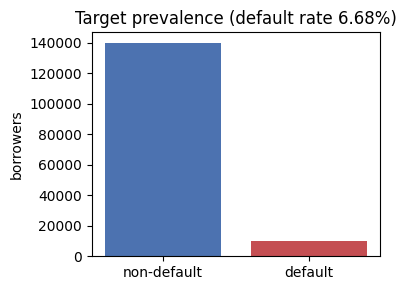

In [4]:
# Target prevalence. Default is a rare event (~6.7%), which is why later notebooks score
# models with PR-AUC (sensitive to the minority class) rather than accuracy.
counts = df["target"].value_counts().rename({0: "non-default", 1: "default"})
rate = df["target"].mean()
print(f"default rate: {rate:.4%}")
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(counts.index.astype(str), counts.values, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("borrowers")
ax.set_title(f"Target prevalence (default rate {rate:.2%})")
plt.tight_layout()
plt.show()

In [5]:
# Per-feature summary statistics. The extreme max values of revolving_utilisation,
# debt_ratio and monthly_income compared with their medians already signal the heavy right
# tails handled later by winsorisation and transformation.
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
target,150000.0,0.07,0.25,0.0,0.00,0.00,0.00,1.0
revolving_utilisation,150000.0,6.05,249.76,0.0,0.03,0.15,0.56,50708.0
age,150000.0,52.30,14.77,0.0,41.00,52.00,63.00,109.0
past_due_30_59,150000.0,0.42,4.19,0.0,0.00,0.00,0.00,98.0
debt_ratio,150000.0,353.01,2037.82,0.0,0.18,0.37,0.87,329664.0
monthly_income,120269.0,6670.22,14384.67,0.0,3400.00,5400.00,8249.00,3008750.0
open_credit_lines_and_loans,150000.0,8.45,5.15,0.0,5.00,8.00,11.00,58.0
past_due_90,150000.0,0.27,4.17,0.0,0.00,0.00,0.00,98.0
real_estate_loans_or_lines,150000.0,1.02,1.13,0.0,0.00,1.00,2.00,54.0
past_due_60_89,150000.0,0.24,4.16,0.0,0.00,0.00,0.00,98.0


In [6]:
# Missing values. Only monthly_income (~20%) and dependents (~2.6%) are incomplete, and
# the dependents gaps are perfectly nested inside the income gaps - every row missing
# dependents is also missing income, so they share one underlying non-response mechanism.
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
})
nested = (df["dependents"].isna() & df["monthly_income"].isna()).sum()
print(f"rows missing dependents that also miss income: {nested:,} "
      f"of {df['dependents'].isna().sum():,} (perfectly nested)")
missing[missing.n_missing > 0]

rows missing dependents that also miss income: 3,924 of 3,924 (perfectly nested)


,n_missing,pct_missing
monthly_income,29731,19.82
dependents,3924,2.62


In [7]:
# Exact duplicate rows (identical on all 11 columns). They are removed before the
# train/validation/test split in Fitting 01, otherwise the same record could appear on
# both sides of the split and leak information.
n_dup = df.duplicated().sum()
print(f"exact duplicate rows: {n_dup:,} (removed before the split in Fitting 01)")

exact duplicate rows: 609 (removed before the split in Fitting 01)


In [8]:
# Sentinel codes. The three past-due counters use 96/98 as special codes rather than real
# episode counts. The affected rows always carry the code in all three columns at once and
# default at ~55% - eight times the baseline - so they are a genuinely high-risk group
# that must be recoded (not deleted) during preprocessing.
past_due_cols = ["past_due_30_59", "past_due_60_89", "past_due_90"]
sentinel_mask = df[past_due_cols].isin([96, 98]).any(axis=1)
pd.DataFrame({
    "rows": [int(sentinel_mask.sum()), int((~sentinel_mask).sum())],
    "default_rate": [df.loc[sentinel_mask, "target"].mean(),
                     df.loc[~sentinel_mask, "target"].mean()],
}, index=["sentinel rows (96/98)", "regular rows"]).round(4)

,rows,default_rate
sentinel rows (96/98),269,0.5465
regular rows,149731,0.0660


In [9]:
# Other implausible values worth tracking: one borrower with age 0, almost a quarter of
# the portfolio (~24%) with debt_ratio >= 1 (debt above income) and utilisation above
# 100%. None of these are deleted; the EDA notebooks below test whether they carry
# signal.
pd.DataFrame({
    "rows": [int((df["age"] == 0).sum()),
             int((df["debt_ratio"] >= 1).sum()),
             int((df["revolving_utilisation"] > 1).sum())],
}, index=["age == 0", "debt_ratio >= 1", "revolving_utilisation > 1"])

,rows
age == 0,1
debt_ratio >= 1,35366
revolving_utilisation > 1,3321


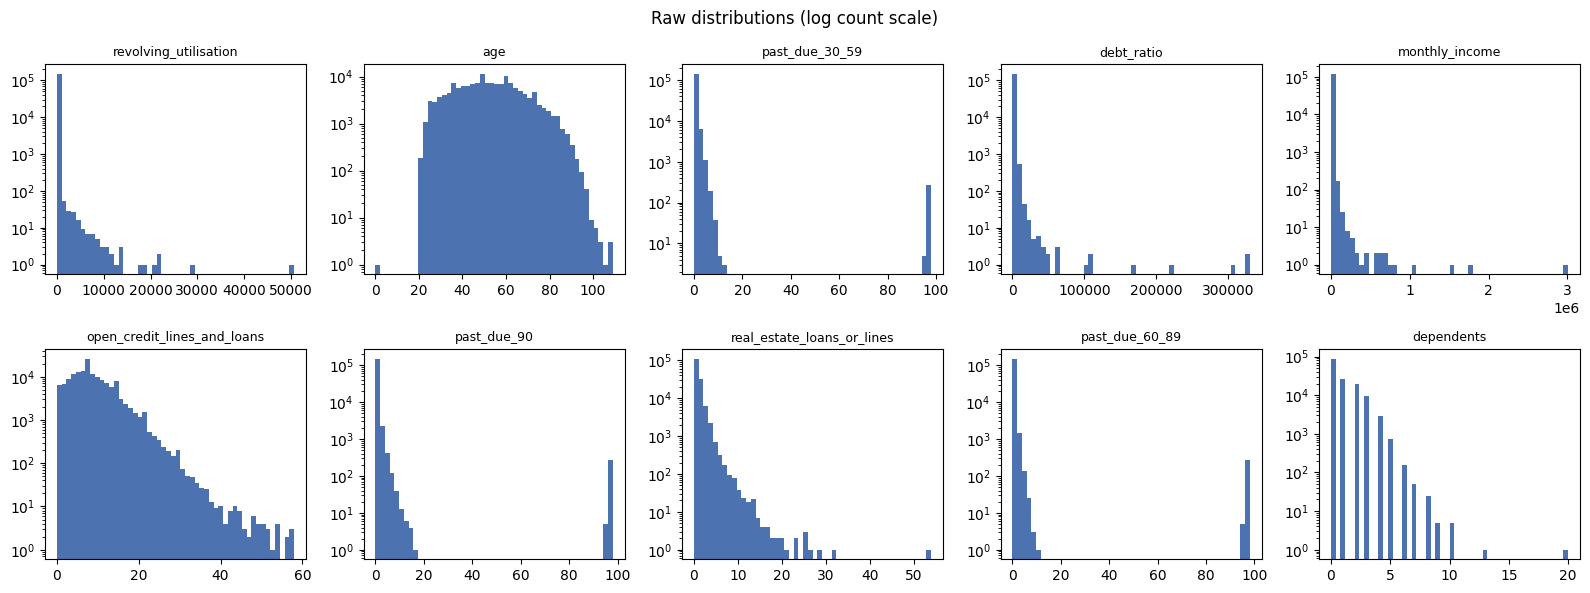

In [10]:
# Raw distributions of the ten predictors. The heavy-tailed features are shown on a log
# count scale so the tail mass is visible at all; this picture motivates the
# transformation study in EDA 03.
features = [c for c in df.columns if c != "target"]
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, col in zip(axes.ravel(), features):
    ax.hist(df[col].dropna(), bins=50, color="#4C72B0")
    ax.set_yscale("log")
    ax.set_title(col, fontsize=9)
fig.suptitle("Raw distributions (log count scale)")
plt.tight_layout()
plt.show()